In [2]:
import pandas as pd

In [4]:
import sys
print(sys.executable)

d:\Anaconda\python.exe


In [5]:
import sys
!{sys.executable} -m pip install yfinance

  Using cached yfinance-1.2.0-py2.py3-none-any.whl.metadata (6.1 kB)
  Using cached multitasking-0.0.12.tar.gz (19 kB)
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Using cached peewee-4.0.4-py3-none-any.whl.metadata (8.6 kB)
  Using cached curl_cffi-0.13.0-cp39-abi3-win_amd64.whl.metadata (13 kB)
Using cached yfinance-1.2.0-py2.py3-none-any.whl (130 kB)
Using cached curl_cffi-0.13.0-cp39-abi3-win_amd64.whl (1.6 MB)
Using cached peewee-4.0.4-py3-none-any.whl (144 kB)
  Created wheel for multitasking: filename=multitasking-0.0.12-py3-none-any.whl size=15702 sha256=e8414c59a670248aed7e56169086497f9b71a6e649dc16aac5afe63dce8552f3
  Stored in directory: c:\users\admin\appdata\local\pip\cache\wheels\1e\df\0f\e

In [6]:
import yfinance as yf

In [16]:
df = yf.download("TATASTEEL.NS", start="2020-01-01", end="2026-04-02")

df

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,TATASTEEL.NS,TATASTEEL.NS,TATASTEEL.NS,TATASTEEL.NS,TATASTEEL.NS
Date,,,,,
2020-01-01,39.250172,39.984408,39.002628,39.690711,121005300
2020-01-02,40.685085,40.932626,39.606807,39.606807,216749610
2020-01-03,40.588577,40.798359,40.231949,40.529839,129568630
2020-01-06,39.711697,40.278107,39.485132,40.278107,96016080
2020-01-07,39.950848,40.664104,39.736869,39.900499,131957880
...,...,...,...,...,...
2026-03-24,190.789993,192.190002,187.779999,192.000000,34321983
2026-03-25,196.649994,197.149994,192.320007,193.029999,34767360


In [17]:
df.to_csv("tatasteel_stock_data.csv")

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1548 entries, 2020-01-01 to 2026-04-01
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   (Close, TATASTEEL.NS)   1548 non-null   float64
 1   (High, TATASTEEL.NS)    1548 non-null   float64
 2   (Low, TATASTEEL.NS)     1548 non-null   float64
 3   (Open, TATASTEEL.NS)    1548 non-null   float64
 4   (Volume, TATASTEEL.NS)  1548 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 72.6 KB


In [ ]:
df.describe()

Price,Close,High,Low,Open,Volume
Ticker,TATASTEEL.NS,TATASTEEL.NS,TATASTEEL.NS,TATASTEEL.NS,TATASTEEL.NS
count,1548.000000,1548.000000,1548.000000,1548.000000,1.548000e+03
mean,110.619165,112.113474,109.203639,110.767422,8.203688e+07
std,45.318513,45.753687,44.888375,45.385030,7.666630e+07
min,21.292852,22.484409,21.049507,22.006110,0.000000e+00
25%,93.053362,94.301858,91.789458,93.424414,3.058758e+07
50%,112.130722,113.745218,110.787943,112.101553,5.388238e+07
75%,146.167339,148.269766,144.629654,146.508337,1.094284e+08
max,215.520004,216.449997,213.009995,215.949997,6.428460e+08


In [20]:
df.isnull().sum()

Price   Ticker      
Close   TATASTEEL.NS    0
High    TATASTEEL.NS    0
Low     TATASTEEL.NS    0
Open    TATASTEEL.NS    0
Volume  TATASTEEL.NS    0
dtype: int64

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

<Figure size 640x480 with 0 Axes>

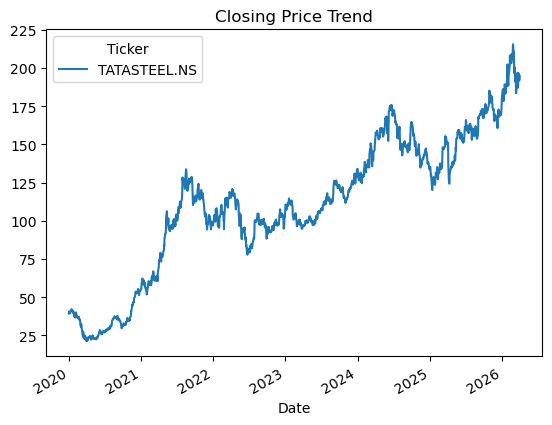

In [22]:
plt.figure()
df['Close'].plot()
plt.title("Closing Price Trend")
plt.show()

<Figure size 640x480 with 0 Axes>

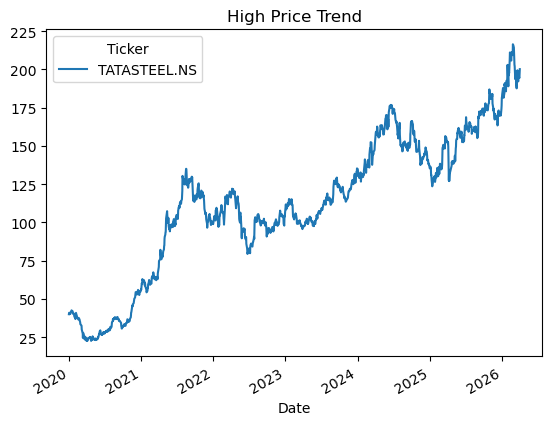

In [24]:
plt.figure()
df['High'].plot()
plt.title("High Price Trend")
plt.show()

In [29]:
df = df.reset_index()

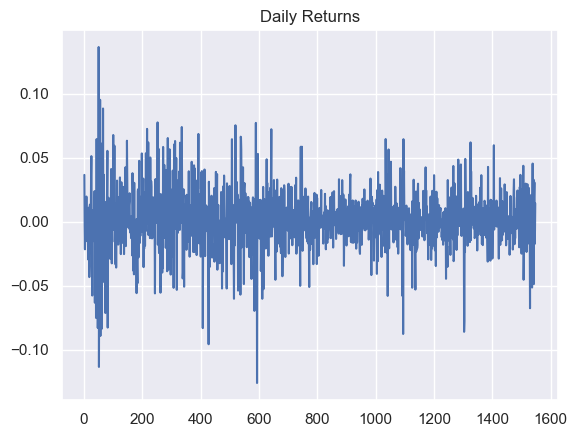

In [31]:
df['Daily Return'] = df['Close'].pct_change()

df['Daily Return'].plot()
plt.title("Daily Returns")
plt.show()

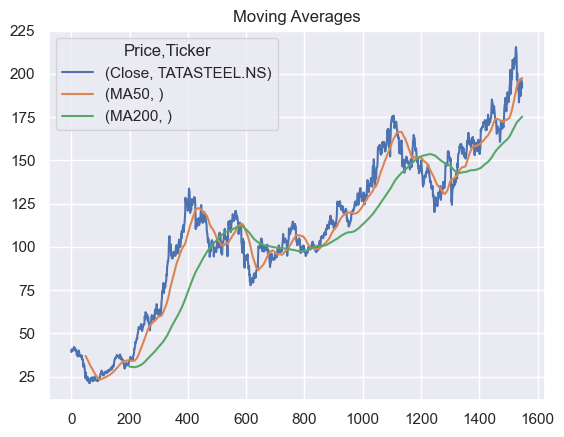

In [32]:
df['MA50'] = df['Close'].rolling(window=50).mean()
df['MA200'] = df['Close'].rolling(window=200).mean()

df[['Close','MA50','MA200']].plot()
plt.title("Moving Averages")
plt.show()

[*********************100%***********************]  3 of 3 completed


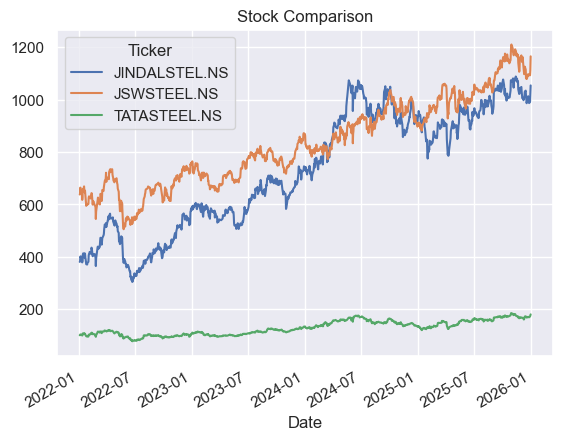

In [33]:
stocks = ["TATASTEEL.NS", "JSWSTEEL.NS", "JINDALSTEL.NS"]

data = yf.download(stocks, start="2022-01-01", end="2026-01-01")['Close']

data.plot()
plt.title("Stock Comparison")
plt.show()

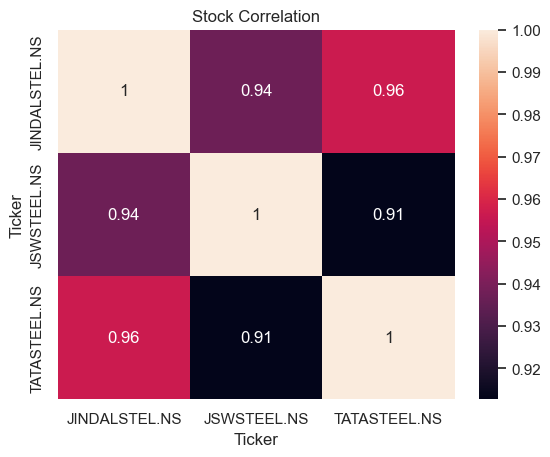

In [34]:
import seaborn as sns

sns.heatmap(data.corr(), annot=True)
plt.title("Stock Correlation")
plt.show()

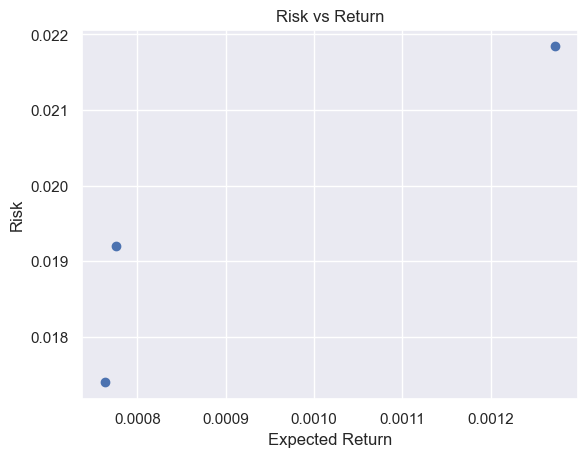

In [37]:
returns = data.pct_change()

plt.scatter(returns.mean(), returns.std())
plt.xlabel("Expected Return")
plt.ylabel("Risk")
plt.title("Risk vs Return")
plt.show()